In [1]:
# ==========================================================
# DeepFER : Facial Emotion Recognition Using Deep Learning
# Part 1 : Import Required Libraries
# ==========================================================

# Operating system related functions
import os

# Random number generation
import random

# Numerical computations
import numpy as np

# Data handling
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Image processing
import cv2

# TensorFlow and Keras
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Dataset splitting
from sklearn.model_selection import train_test_split

# Performance evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("✅ All Libraries Imported Successfully")

✅ All Libraries Imported Successfully


In [2]:
# ==========================================================
# Check TensorFlow Version
# ==========================================================

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [3]:
# ==========================================================
# Check GPU Availability
# ==========================================================

print("GPU Available :", tf.config.list_physical_devices('GPU'))

GPU Available : []


In [4]:
# ==========================================================
# Set Random Seed
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Random Seed Set Successfully")

✅ Random Seed Set Successfully


In [5]:
# ==========================================================
# Dataset Path
# ==========================================================

DATASET_PATH = r"C:\Users\MAHESH KUMAR\Downloads\archive-3"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Training Folder :", TRAIN_DIR)
print("Testing Folder  :", TEST_DIR)

Training Folder : C:\Users\MAHESH KUMAR\Downloads\archive-3\train
Testing Folder  : C:\Users\MAHESH KUMAR\Downloads\archive-3\test


In [6]:
# ==========================================================
# Emotion Labels
# ==========================================================

EMOTIONS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("Emotion Classes")
print(EMOTIONS)

Emotion Classes
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
# ==========================================================
# Check Dataset Availability
# ==========================================================

if os.path.exists(TRAIN_DIR):
    print("✅ Training Folder Found")
else:
    print("❌ Training Folder NOT Found")

if os.path.exists(TEST_DIR):
    print("✅ Testing Folder Found")
else:
    print("❌ Testing Folder NOT Found")

✅ Training Folder Found
✅ Testing Folder Found


In [8]:
# ==========================================================
# Count Images in Training Dataset
# ==========================================================

print("=" * 40)
print("Training Dataset Summary")
print("=" * 40)

total_images = 0

for emotion in EMOTIONS:

    folder = os.path.join(TRAIN_DIR, emotion)

    if os.path.exists(folder):

        count = len(os.listdir(folder))

        total_images += count

        print(f"{emotion:<10} : {count}")

print("=" * 40)
print("Total Images :", total_images)

Training Dataset Summary
angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171
Total Images : 28709


In [9]:
# ==========================================================
# Image Configuration
# ==========================================================

IMAGE_SIZE = (48, 48)     # FER2013 image size
BATCH_SIZE = 32
COLOR_MODE = "grayscale"  # FER2013 is grayscale

print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)
print("Color Mode :", COLOR_MODE)

Image Size : (48, 48)
Batch Size : 32
Color Mode : grayscale


In [10]:
# ==========================================================
# Image Data Generator
# ==========================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

print("✅ Data Generators Created Successfully")

✅ Data Generators Created Successfully


In [11]:
# ==========================================================
# Load Training Dataset
# ==========================================================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

print("✅ Training Dataset Loaded Successfully")

Found 28709 images belonging to 7 classes.
✅ Training Dataset Loaded Successfully


In [12]:
# ==========================================================
# Load Testing Dataset
# ==========================================================

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("✅ Testing Dataset Loaded Successfully")

Found 7178 images belonging to 7 classes.
✅ Testing Dataset Loaded Successfully


In [13]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("=" * 50)
print("TRAINING IMAGES :", train_generator.samples)
print("TEST IMAGES     :", test_generator.samples)
print("NUMBER OF CLASSES :", train_generator.num_classes)
print("=" * 50)

print("\nClass Labels")

print(train_generator.class_indices)

TRAINING IMAGES : 28709
TEST IMAGES     : 7178
NUMBER OF CLASSES : 7

Class Labels
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


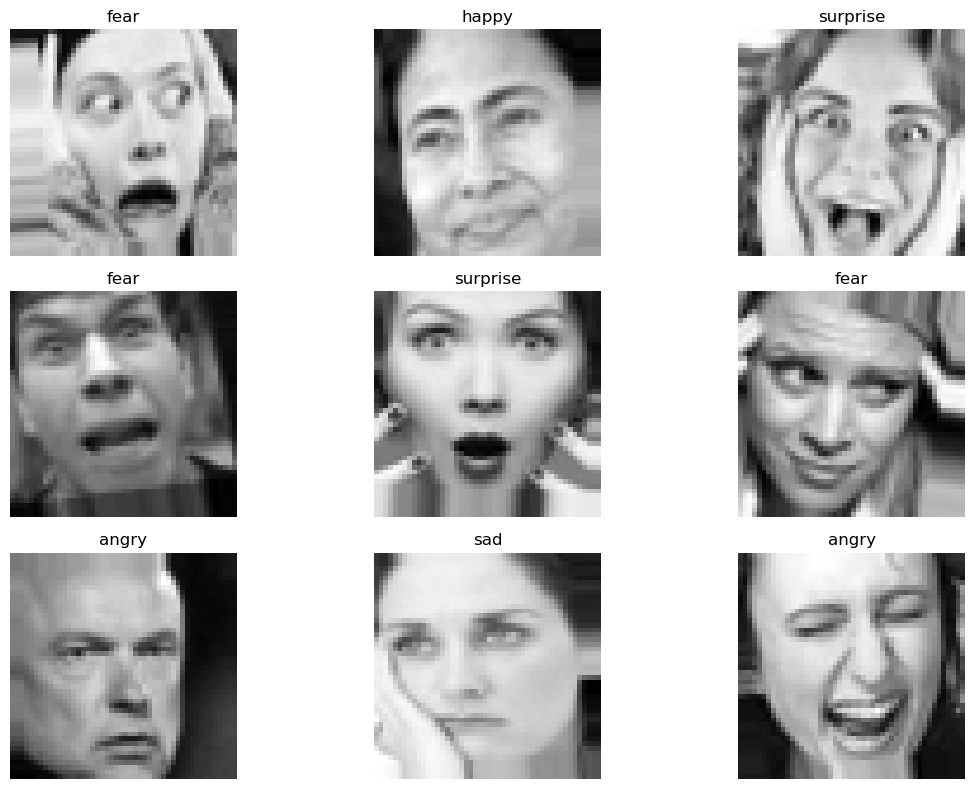

In [14]:
# ==========================================================
# Display Sample Images
# ==========================================================

images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].reshape(48,48), cmap='gray')

    label = np.argmax(labels[i])

    plt.title(EMOTIONS[label])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [15]:
# ==========================================================
# Generator Information
# ==========================================================

print("Input Shape :", train_generator.image_shape)

print("Batch Shape :", images.shape)

print("Label Shape :", labels.shape)

Input Shape : (48, 48, 1)
Batch Shape : (32, 48, 48, 1)
Label Shape : (32, 7)


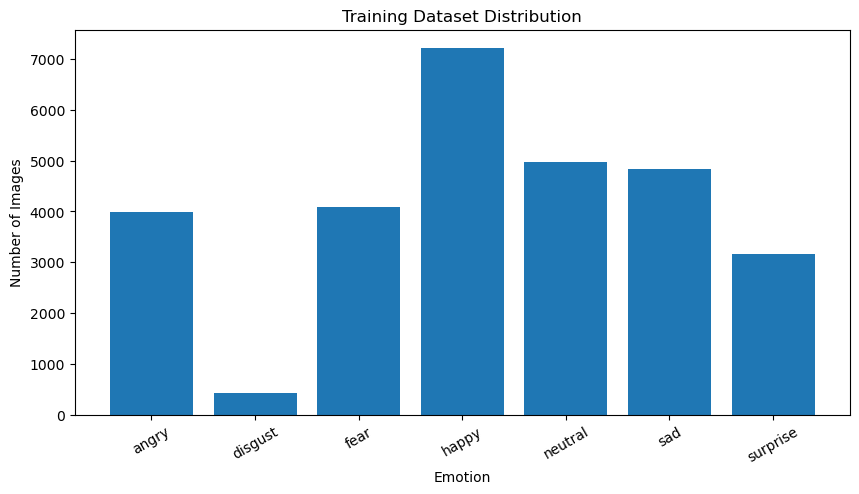

In [16]:
# ==========================================================
# Plot Training Dataset Distribution
# ==========================================================

class_counts = []

for emotion in EMOTIONS:

    folder = os.path.join(TRAIN_DIR, emotion)

    class_counts.append(len(os.listdir(folder)))

plt.figure(figsize=(10,5))

plt.bar(EMOTIONS, class_counts)

plt.title("Training Dataset Distribution")

plt.xlabel("Emotion")

plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.show()

In [17]:
# ==========================================================
# Final Verification
# ==========================================================

print("=" * 50)

print("Training Samples :", train_generator.samples)

print("Testing Samples  :", test_generator.samples)

print("Classes          :", train_generator.class_indices)

print("Image Shape      :", train_generator.image_shape)

print("=" * 50)

Training Samples : 28709
Testing Samples  : 7178
Classes          : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Image Shape      : (48, 48, 1)


In [18]:
# ==========================================================
# DeepFER
# Part 3 : Build CNN Model
# ==========================================================

# Create Sequential Model
model = Sequential()

# ==========================================================
# Block 1
# ==========================================================

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(48,48,1)
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# ==========================================================
# Block 2
# ==========================================================

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# ==========================================================
# Block 3
# ==========================================================

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# ==========================================================
# Convert Feature Maps to 1D
# ==========================================================

model.add(Flatten())

# ==========================================================
# Fully Connected Layer
# ==========================================================

model.add(Dense(512, activation='relu'))

model.add(BatchNormalization())

model.add(Dropout(0.50))

# ==========================================================
# Output Layer
# ==========================================================

model.add(Dense(7, activation='softmax'))

print("✅ CNN Model Created Successfully")

C:\Users\MAHESH KUMAR\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ CNN Model Created Successfully


In [19]:
# ==========================================================
# Display Model Summary
# ==========================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,653,671 (10.12 MB)

 Trainable params: 2,651,751 (10.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [20]:
# ==========================================================
# Count Model Parameters
# ==========================================================

print("Total Parameters :", model.count_params())

Total Parameters : 2653671


In [21]:
# ==========================================================
# Model Input / Output Shape
# ==========================================================

print("Input Shape  :", model.input_shape)

print("Output Shape :", model.output_shape)

Input Shape  : (None, 48, 48, 1)
Output Shape : (None, 7)


In [22]:
# ==========================================================
# Display All Layers
# ==========================================================

print("="*60)

for i, layer in enumerate(model.layers):

    print(f"{i+1:02d}. {layer.name:25s} {layer.output.shape}")

print("="*60)

01. conv2d                    (None, 48, 48, 32)
02. batch_normalization       (None, 48, 48, 32)
03. conv2d_1                  (None, 48, 48, 32)
04. batch_normalization_1     (None, 48, 48, 32)
05. max_pooling2d             (None, 24, 24, 32)
06. dropout                   (None, 24, 24, 32)
07. conv2d_2                  (None, 24, 24, 64)
08. batch_normalization_2     (None, 24, 24, 64)
09. conv2d_3                  (None, 24, 24, 64)
10. batch_normalization_3     (None, 24, 24, 64)
11. max_pooling2d_1           (None, 12, 12, 64)
12. dropout_1                 (None, 12, 12, 64)
13. conv2d_4                  (None, 12, 12, 128)
14. batch_normalization_4     (None, 12, 12, 128)
15. conv2d_5                  (None, 12, 12, 128)
16. batch_normalization_5     (None, 12, 12, 128)
17. max_pooling2d_2           (None, 6, 6, 128)
18. dropout_2                 (None, 6, 6, 128)
19. flatten                   (None, 4608)
20. dense                     (None, 512)
21. batch_normalization_6     (

In [23]:
# ==========================================================
# Final Verification
# ==========================================================

print("Model Name :", model.name)

print("Number of Layers :", len(model.layers))

print("Output Classes :", model.output_shape[-1])

Model Name : sequential
Number of Layers : 23
Output Classes : 7


In [24]:
# Create Adam Optimizer
optimizer = Adam(
    learning_rate=0.0001
)

# Compile Model
model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [25]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=8,

    restore_best_weights=True,
)


In [26]:
checkpoint = ModelCheckpoint(

    filepath="DeepFER_Best_Model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [27]:
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [28]:
train_dir = r"C:\Users\MAHESH KUMAR\Downloads\archive-3\train"
test_dir = r"C:\Users\MAHESH KUMAR\Downloads\archive-3\test"

In [29]:
print(os.path.exists(train_dir))
print(os.path.exists(test_dir))

True
True


In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [31]:
BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model architecture directly in your session
def create_deepfer_model(input_shape=(48, 48, 1), num_classes=7):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Now call the function
NUM_CLASSES = 7  # Adjust based on your dataset categories
model = create_deepfer_model(input_shape=(48, 48, 1), num_classes=NUM_CLASSES)

In [33]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save best model
checkpoint = ModelCheckpoint(
    "DeepFER_Best_Model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [35]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.2148 - loss: 1.9831
Epoch 1: val_accuracy improved from None to 0.25871, saving model to DeepFER_Best_Model.keras

Epoch 1: finished saving model to DeepFER_Best_Model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 297s 640ms/step - accuracy: 0.2148 - loss: 1.9831 - val_accuracy: 0.2587 - val_loss: 1.8137
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.2376 - loss: 1.8438
Epoch 2: val_accuracy improved from 0.25871 to 0.28699, saving model to DeepFER_Best_Model.keras

Epoch 2: finished saving model to DeepFER_Best_Model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 282s 628ms/step - accuracy: 0.2376 - loss: 1.8438 - val_accuracy: 0.2870 - val_loss: 1.7690
Epoch 3/30
399/449 ━━━━━━━━━━━━━━━━━━━━ 29s 590ms/step - accuracy: 0.2470 - loss: 1.8250
Epoch 4: val_accuracy improved from 0.28727 to 0.30412, saving model to DeepFER_Best_Model.keras

Epoch 4: finished saving model to DeepFER_Best_Model.keras
449/449 ━━━━━━━━━━━━━━━━━

In [36]:
model.save("DeepFER_Final_Model.keras")

print("✅ Final Model Saved Successfully")

✅ Final Model Saved Successfully


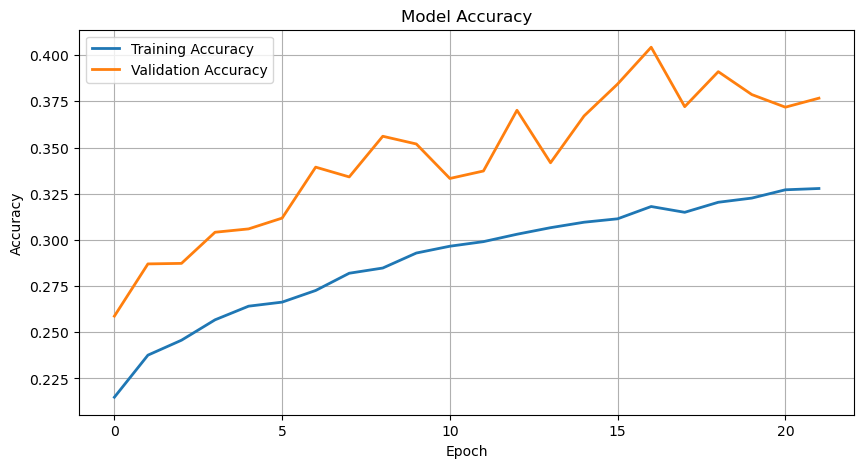

In [37]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

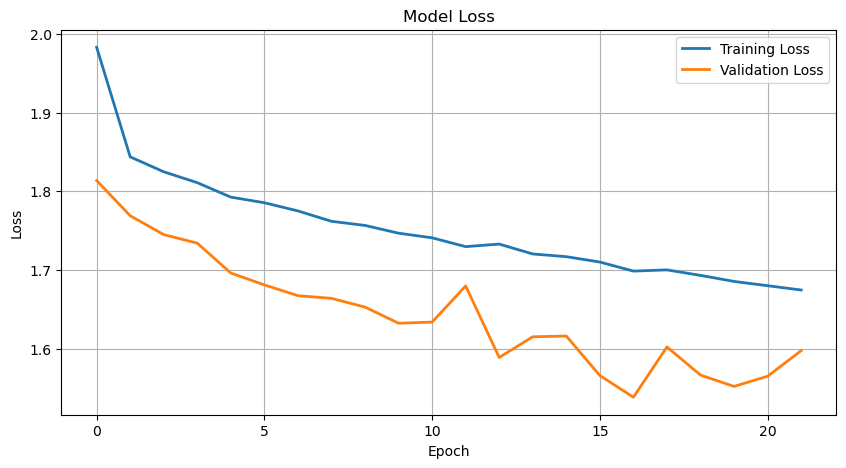

In [38]:
# ==========================================================
# Plot Training & Validation Loss
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [39]:
# ==========================================================
# Evaluate Model
# ==========================================================

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 50)

113/113 ━━━━━━━━━━━━━━━━━━━━ 23s 204ms/step - accuracy: 0.4043 - loss: 1.5385
Test Loss     : 1.5385
Test Accuracy : 40.43%


In [40]:
# ==========================================================
# Reset Test Generator
# ==========================================================

test_generator.reset()

In [41]:
# ==========================================================
# Predict Test Images
# ==========================================================

predictions = model.predict(
    test_generator,
    verbose=1
)

predicted_classes = predictions.argmax(axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("✅ Prediction Completed Successfully")

113/113 ━━━━━━━━━━━━━━━━━━━━ 26s 225ms/step
✅ Prediction Completed Successfully


In [42]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

       angry       0.39      0.01      0.02       958
     disgust       0.00      0.00      0.00       111
        fear       0.23      0.08      0.12      1024
       happy       0.43      0.82      0.57      1774
     neutral       0.39      0.41      0.40      1233
         sad       0.31      0.22      0.26      1247
    surprise       0.46      0.68      0.55       831

    accuracy                           0.40      7178
   macro avg       0.32      0.32      0.27      7178
weighted avg       0.37      0.40      0.34      7178



C:\Users\MAHESH KUMAR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MAHESH KUMAR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MAHESH KUMAR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[  11    0   61  422  182  165  117]
 [   0    0    4   61   19   20    7]
 [   3    0   86  375  158  152  250]
 [   3    0   36 1458  104   76   97]
 [   0    0   47  411  503  177   95]
 [   7    0   78  524  257  279  102]
 [   4    0   54  118   57   33  565]]


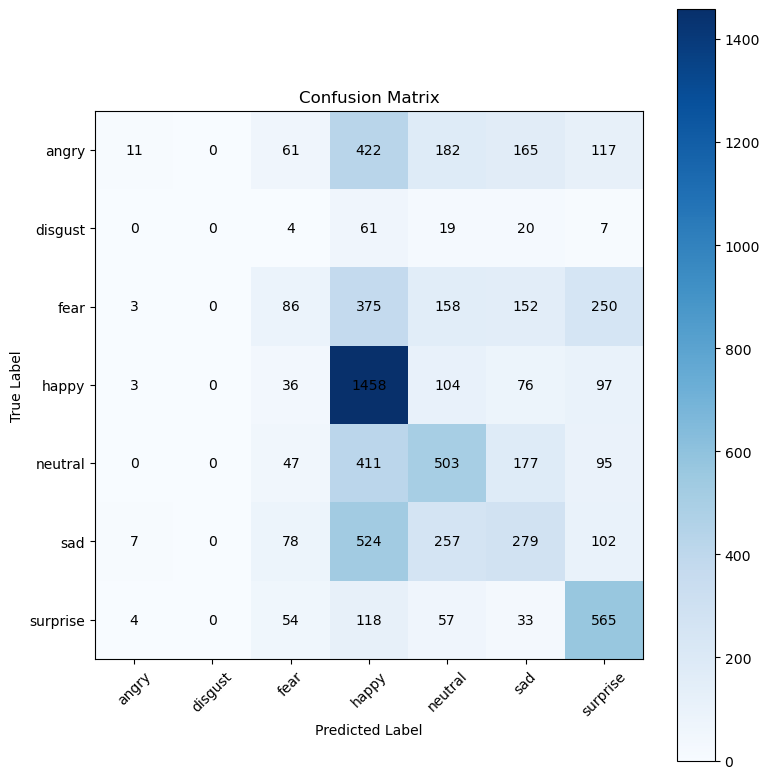

In [44]:
# ==========================================================
# Plot Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_labels))

plt.xticks(tick_marks, class_labels, rotation=45)

plt.yticks(tick_marks, class_labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.show()

In [45]:
# ==========================================================
# Final Model Summary
# ==========================================================

print("=" * 60)

print(f"Final Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Total Test Images   : {len(true_classes)}")
print(f"Number of Classes   : {len(class_labels)}")

print("=" * 60)
print("✅ Model Evaluation Completed Successfully")

Final Test Accuracy : 40.43%
Total Test Images   : 7178
Number of Classes   : 7
✅ Model Evaluation Completed Successfully


In [46]:
# ==========================================================
# Real-Time Emotion Detection
# ==========================================================

import cv2
import numpy as np
from tensorflow.keras.models import load_model

In [47]:
# Load Trained Model

model = load_model("DeepFER_Final_Model.keras")

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [48]:
model = load_model("DeepFER_Best_Model.keras")

In [49]:
EMOTIONS = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

In [50]:
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

print("✅ Face Detector Loaded")

✅ Face Detector Loaded


In [ ]:
Real-Time Emotion Detection


if not cap.isOpened():
    print("❌ Camera Not Found")
    exit()

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_classifier.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:

        roi = gray[y:y+h, x:x+w]

        roi = cv2.resize(roi, (48,48))

        roi = roi.astype("float32") / 255.0

        roi = np.expand_dims(roi, axis=-1)

        roi = np.expand_dims(roi, axis=0)

        prediction = model.predict(roi, verbose=0)

        emotion_index = np.argmax(prediction)

        confidence = np.max(prediction)

        emotion = EMOTIONS[emotion_index]

        cv2.rectangle(
            frame,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            f"{emotion} ({confidence*100:.1f}%)",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

    cv2.imshow("DeepFER Emotion Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()

cv2.destroyAllWindows()

In [ ]:
# Close Webcam Safely

cap.release()
cv2.destroyAllWindows()

print("✅ Camera Closed Successfully")

In [ ]:
import cv2

try:
    cap.release()
except:
    pass

cv2.destroyAllWindows()

# Wait briefly for windows to close
cv2.waitKey(1)

print("✅ All OpenCV Windows Closed")